                                        HELP ONG

             Awa Diaw •  Moussa Diémé •  Ndeye Ramatoulaye N. Fall  •  Hildegarde E. Biyenda


> SigmaPulse: Calculated compassion, where Data Science meets human dignity.


                 **PROJET DE Machine learning 2 : Fusion des datasets**



Ce notebook constitue la `première étape` du pipeline de traitement du projet académique SigmaPulse. Une base initiale de données nous a été fournie dans le cadre du projet, mais afin d’enrichir la capacité analytique du modèle et d’obtenir une vision plus complète des dynamiques humanitaires, socio-économiques et sécuritaires des pays, un travail de data augmenting a été réalisé à partir de plusieurs sources complémentaires.

L’objectif de ce script `P0_init-merge.ipynb` est donc de centraliser, harmoniser et fusionner l’ensemble des jeux de données disponibles en une base unifiée, cohérente et exploitable pour les étapes ultérieures d’analyse exploratoire, de réduction dimensionnelle et de clustering des pays pour l’allocation optimisée de l’aide humanitaire par l'ONG Help International.


# Section 0 : Chargement des packages

In [346]:
import pandas as pd # Utilisé pour la manipulation et l'analyse des données
import pycountry # Utilisé pour la recherche d'informations sur les pays, comme les codes ISO
import matplotlib.pyplot as plt # Utilisé pour créer des visualisations statiques, animées et interactives en Python
import seaborn as sns # Utilisé pour la visualisation statistique des données, basé sur Matplotlib
from matplotlib.patches import Patch # Utilisé pour créer des entrées de légende personnalisées dans les graphiques Matplotlib
from pathlib import Path # Utilisé pour la gestion des chemins de fichiers de manière orientée objet

raw_dir = Path('/content/')

# Section 1 : Chargement des bases de données

## 1.Main dataset

Il s'agit du jeu de données principal proposé par le professeur.

In [347]:
# Charge le jeu de données principal depuis 'Country-data.xlsx' dans un DataFrame.
# Crée une copie du DataFrame principal pour préserver l'original.
# Affiche des informations sur le DataFrame, y compris les types de données et le nombre de valeurs non nulles.
df_main=pd.read_excel(raw_dir/"Country-data.xlsx")
df_final = df_main.copy()
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [348]:
# Affiche les 5 premières lignes du DataFrame principal
df_main.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [349]:
# Définit une fonction pour obtenir le code ISO Alpha-3 d'un pays donné en utilisant la bibliothèque pycountry.
# Applique cette fonction à la colonne 'country' de df_final pour créer une nouvelle colonne 'iso_code'.
def get_iso_code(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except (LookupError, AttributeError):
        return None

df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [350]:
# Définit un dictionnaire pour les corrections manuelles des noms de pays que pycountry pourrait ne pas reconnaître directement.
mapping_corrections = {
    'Brunei': 'Brunei Darussalam',
    'Cape Verde': 'Cabo Verde',
    'Congo, Dem. Rep.': 'Congo, The Democratic Republic of the',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Macedonia, FYR': 'North Macedonia',
    'Micronesia, Fed. Sts.': 'Micronesia, Federated States of',
    'Russia': 'Russian Federation',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines',
    'Turkey': 'Türkiye'
}

# Applique les corrections à la colonne 'country' dans df_final.
df_final['country'] = df_final['country'].replace(mapping_corrections)

# Réapplique le mappage des codes ISO après les corrections des noms de pays.
df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [351]:
# Vérifie s'il reste des codes ISO manquants après les corrections.
missing_after = df_final[df_final['iso_code'].isna()]

# Affiche un message de succès ou une liste de pays avec des codes ISO manquants.
if missing_after.empty:
    print("Succès total : Tous les pays ont désormais un code ISO Alpha-3.")
else:
    print(f"Il reste encore des anomalies pour : {missing_after['country'].unique()}")

# Valide la cohérence dimensionnelle : s'assure que chaque ligne a un code ISO unique.
n_lignes = len(df_final)
n_uniques = df_final['iso_code'].nunique()

print(f"Nombre total de lignes : {n_lignes}")
print(f"Nombre de codes ISO uniques : {n_uniques}")

if n_lignes == n_uniques:
    print("L'intégrité référentielle est parfaite : un code unique par ligne.")

Succès total : Tous les pays ont désormais un code ISO Alpha-3.
Nombre total de lignes : 167
Nombre de codes ISO uniques : 167
L'intégrité référentielle est parfaite : un code unique par ligne.


In [352]:
# Affiche les premières lignes du DataFrame final, incluant désormais la colonne 'iso_code'.
df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG


## 2.Dimension Santé WDI et WHO

### 2a.Dimension Santé WDI

Les indicateurs de santé sont généralement collectés annuellement, mais certains pays peuvent avoir un décalage. Nous extrayons 2014, mais pour les données très sporadiques (comme le nombre de médecins), nous vérifierons la pertinence d'une fenêtre temporelle de 2012-2016.

> Ajouter une citation



In [353]:
df_wdi = pd.read_csv('data_raw_health_WDI.csv')
df_wdi.head()
# Renommer les modalités de la variable 'Series'
series_mapping = {

    'SH.DYN.MORT':      'child_mortality',          # Mortalité infantile < 5 ans (pour 1000)
    'SP.DYN.LE00.IN':   'life_expectancy',           # Espérance de vie à la naissance
    'SH.STA.MMRT':      'maternal_mortality',        # Mortalité maternelle (pour 100k naissances)
    'SH.IMM.IDPT':      'vaccination_dpt',           # Couverture vaccinale DPT (% enfants)
    'SH.XPD.CHEX.GD.ZS':'health_expenditure_pct_gdp',# Dépenses de santé (% PIB)
    'SH.MED.PHYS.ZS':   'physicians_per_1000',       # Médecins (pour 1000 habitants)
    'SH.DYN.AIDS.ZS':   'hiv_prevalence',            # Prévalence VIH (% pop. 15-49)
    'SH.TBS.INCD':      'tb_incidence',              # Incidence tuberculose (pour 100k)
}

# Application du mapping
df_wdi["series"] = df_wdi["series"].replace(series_mapping)

# Vérification
print(sorted(df_wdi["series"].unique()))

['child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence', 'life_expectancy', 'maternal_mortality', 'physicians_per_1000', 'tb_incidence', 'vaccination_dpt']


In [354]:

# Définit des mappages spécifiques pour les pays nécessitant une correction forcée du code ISO.
wdi_to_iso_final = {
    'Turkiye': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM',
    'Congo, Dem. Rep.': 'COD',
    'Congo, Rep.': 'COG',
    "Cote d'Ivoire": 'CIV',
    'St. Vincent and the Grenadines': 'VCT',
    'Yemen, Rep.': 'YEM',
    'Venezuela, RB': 'VEN',
    'Egypt, Arab Rep.': 'EGY',
    'Korea, Rep.': 'KOR',
    'Iran, Islamic Rep.': 'IRN',
    'Gambia, The': 'GMB',
    'Bahamas, The': 'BHS',
    'Lao PDR': 'LAO',
    # Ajouts pour combler les manques
    'Türkiye': 'TUR',
    'Turkey': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM'
}

# Mappe automatiquement les noms de pays aux codes ISO en utilisant la fonction get_iso_code.
df_wdi['iso_code'] = df_wdi['Country'].apply(get_iso_code)

# Remplit les codes ISO manquants en utilisant le mappage prédéfini wdi_to_iso_final.
df_wdi['iso_code'] = df_wdi['iso_code'].fillna(df_wdi['Country'].map(wdi_to_iso_final))

# Filtre le DataFrame WDI pour inclure uniquement les pays présents dans le df_final principal.
iso_reference = df_final['iso_code'].unique()
df_wdi = df_wdi[df_wdi['iso_code'].isin(iso_reference)].copy()


# --- DIAGNOSTIC DE VÉRIFICATION ---
# Vérifie le nombre de codes ISO uniques dans le DataFrame de référence et le DataFrame WDI.
iso_f = set(df_final['iso_code'].unique())
iso_w = set(df_wdi['iso_code'].unique())

print(f"Nombre de pays (Référentiel) : {len(iso_f)}")
print(f"Nombre de pays (WDI)         : {len(iso_w)}")
print(f"Intersection                 : {len(iso_f & iso_w)}")

# Signale tous les codes ISO encore manquants après la réconciliation.
if iso_f - iso_w:
    print(f"Codes toujours manquants     : {iso_f - iso_w}")
else:
    print("Succès : Les 167 pays sont désormais alignés.")

Nombre de pays (Référentiel) : 167
Nombre de pays (WDI)         : 167
Intersection                 : 167
Succès : Les 167 pays sont désormais alignés.


In [355]:
# Affiche les 2 premières lignes du DataFrame WDI traité pour vérifier sa structure.
df_wdi.head(2)

,economy,series,Country,Series,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,iso_code
1,ZMB,child_mortality,Zambia,"Mortality rate, under-5 (per 1,000 live births)",62.6,60.2,57.1,55.2,54.7,53.5,52.5,50.4,49.5,49.1,ZMB
2,YEM,child_mortality,"Yemen, Rep.","Mortality rate, under-5 (per 1,000 live births)",48.7,49.3,47.9,47.5,47.3,46.1,43.4,42.6,41.1,39.5,YEM


In [356]:
# Filtre les données WDI pour inclure uniquement la colonne 'YR2014' et marque les valeurs manquantes.
df_2014 = df_wdi[['iso_code', 'Country', 'series', 'YR2014']].copy()
df_2014['is_na'] = df_2014['YR2014'].isna()

# Regroupe par 'Series' (indicateur) pour calculer le nombre et la proportion de valeurs manquantes.
stats_vars = df_2014.groupby('series')['is_na'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)
stats_vars.columns = ['Nombre de NA', 'Proportion de NA']
stats_vars['Proportion de NA'] = stats_vars['Proportion de NA'].map('{:.1%}'.format)

# Affiche le résumé des valeurs manquantes par variable pour 2014.
print("Bilan des manquants par variable en 2014 :")
print(stats_vars)

Bilan des manquants par variable en 2014 :
                            Nombre de NA Proportion de NA
series                                                   
physicians_per_1000                   57            34.1%
hiv_prevalence                        31            18.6%
health_expenditure_pct_gdp             1             0.6%
child_mortality                        0             0.0%
life_expectancy                        0             0.0%
maternal_mortality                     0             0.0%
tb_incidence                           0             0.0%
vaccination_dpt                        0             0.0%


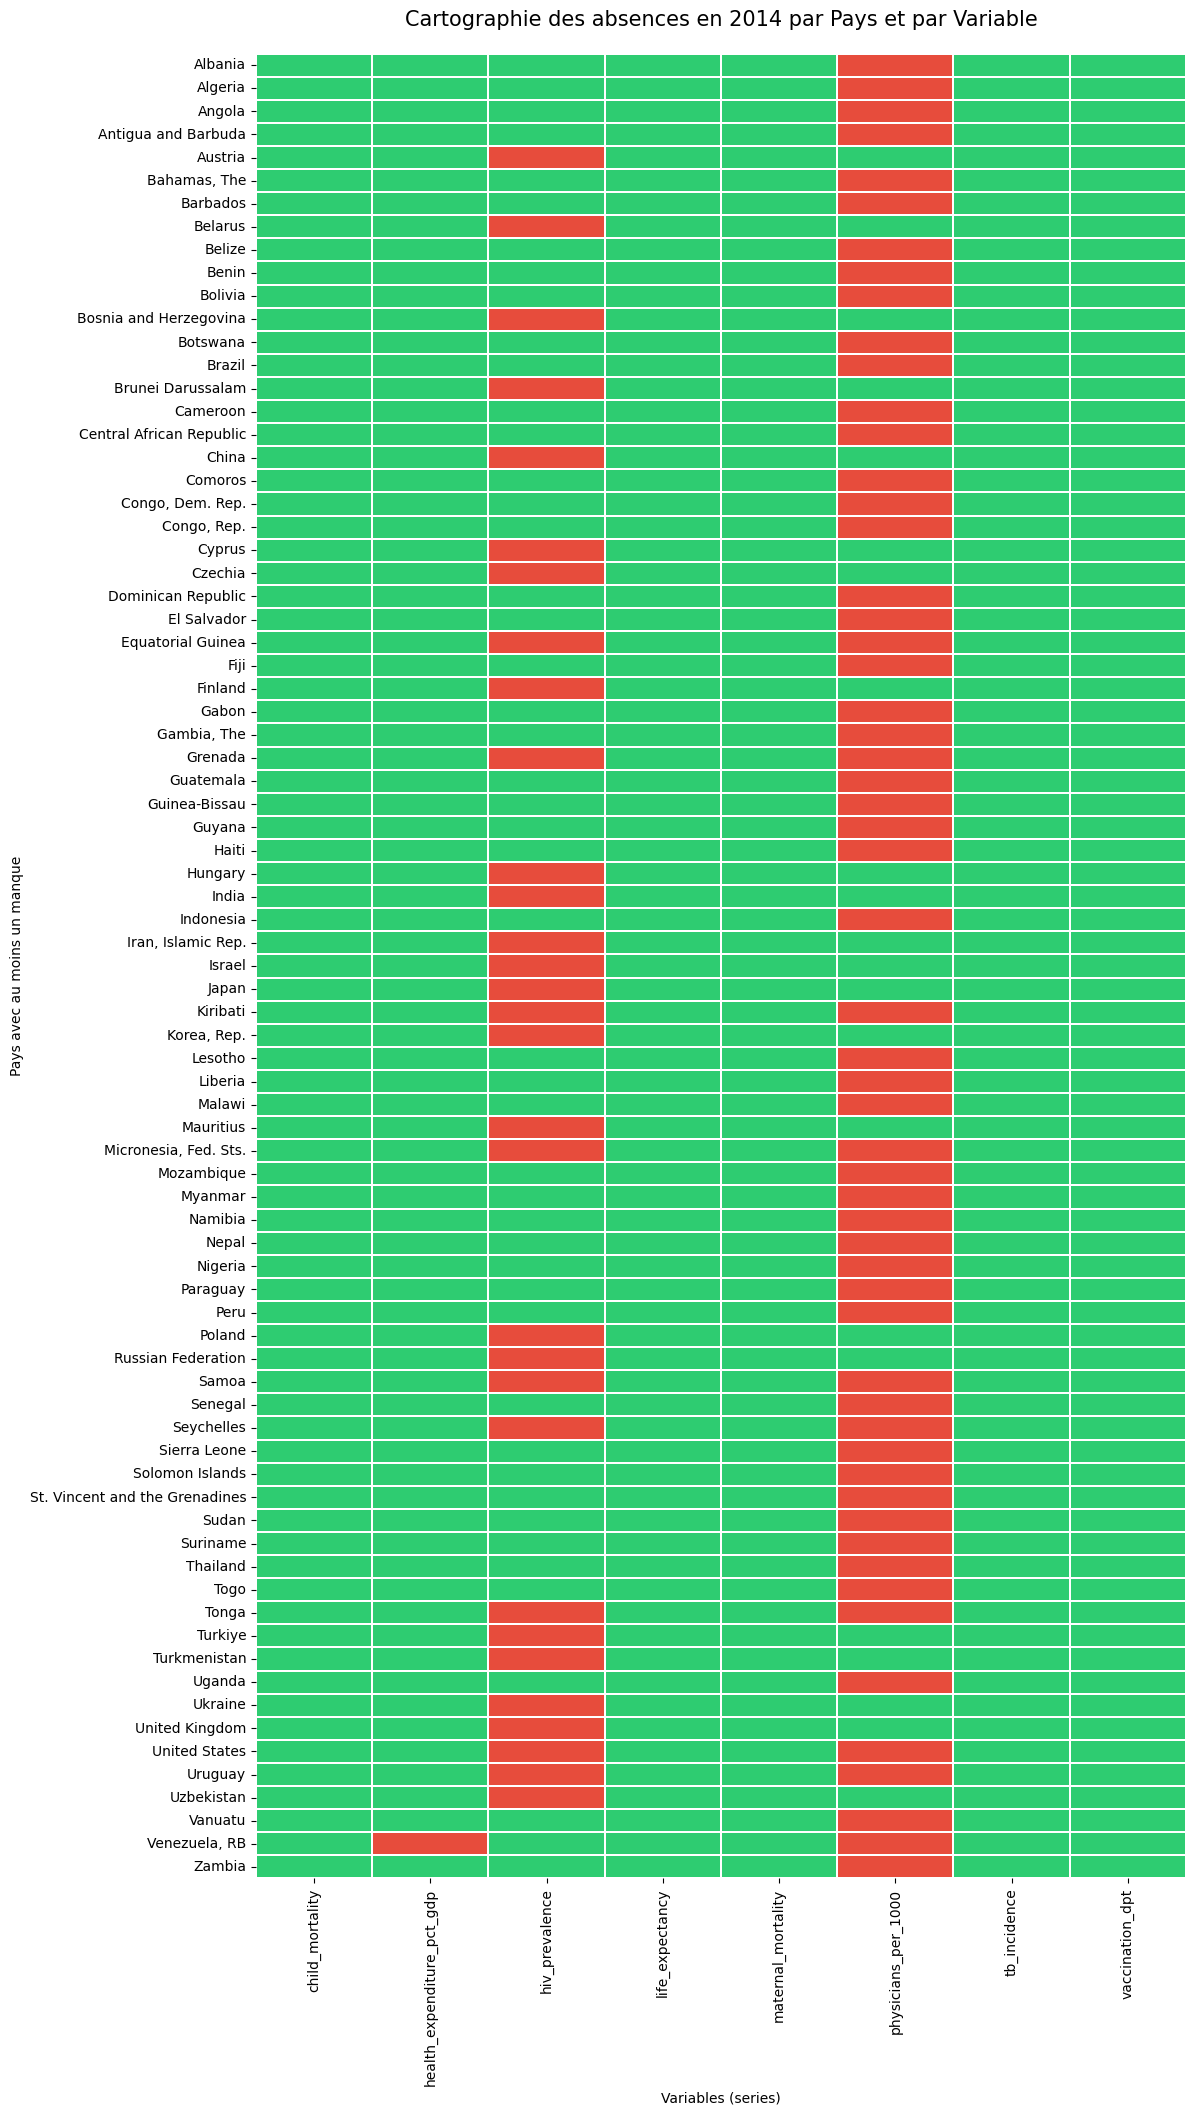

In [357]:
# Pivote le DataFrame pour avoir 'Series' comme colonnes et 'Country' comme index, avec des valeurs booléennes de NA.
df_pivot_2014 = df_2014.pivot(index='Country', columns='series', values='is_na')

# Filtre pour afficher uniquement les pays qui ont au moins une valeur manquante.
df_na_only = df_pivot_2014[df_pivot_2014.any(axis=1)]

# Crée une carte de chaleur (heatmap) pour visualiser les motifs de données manquantes par pays et par variable.
plt.figure(figsize=(12, max(10, len(df_na_only) * 0.3)))
sns.heatmap(df_na_only, cmap=['#2ecc71', '#e74c3c'], cbar=False, linewidths=0.1)

# Ajoute une légende personnalisée pour la carte de chaleur.
plt.title("Cartographie des absences en 2014 par Pays et par Variable", fontsize=15, pad=20)
plt.xlabel("Variables (series)")
plt.ylabel("Pays avec au moins un manque")
plt.show()

> Le taux de médecins (physicians_per_1000) présente 34,1% de valeurs manquantes (NA) en 2014.
Vérifions si l'élargissement de la fenêtre permet de récupérer ces pays.

**Recherche sur 2015-2017**

L'alphabétisation, le taux de pauvreté ou le nombre de médecins pour 1000 habitants sont des variables à forte inertie. Elles évoluent lentement au fil des années. Un taux d'alphabétisation de 2012 est un proxy acceptable pour 2014.

> Pour les données de santé/social, les NA sont souvent dus à la périodicité des recensements (qui ont lieu tous les 5 à 10 ans). Le manque est donc conjoncturel.

 Que se passe-t-il si un pays a subi un effondrement économique, une épidémie (ex: Ebola en Afrique de l'Ouest en 2014-2015) ou un changement de régime entre 2014 et 2018 ?

In [358]:
# Convertit les colonnes d'années pertinentes en numérique, en forçant les erreurs à NaN.
years = ['YR2014', 'YR2015', 'YR2016', 'YR2017']
for yr in years:
    df_wdi[yr] = pd.to_numeric(df_wdi[yr], errors='coerce')

# Identifie les valeurs NA initiales dans 'YR2014' avant le remplissage par propagation arrière.
initial_na = df_wdi['YR2014'].isna()

# Applique le remplissage par propagation arrière : tente de remplir les valeurs NA dans 'YR2014' avec les données de 'YR2015', puis 'YR2016', puis 'YR2017'.
df_wdi['YR2014'] = df_wdi['YR2014'].fillna(df_wdi['YR2015']) \
                                   .fillna(df_wdi['YR2016']) \
                                   .fillna(df_wdi['YR2017'])

# Encode le statut de chaque point de données : 0 = Original, 1 = Récupéré via remplissage par propagation arrière, 2 = Toujours absent.
df_wdi['status'] = 0
# Si c'était NA initialement ET que c'est maintenant rempli, définit le statut à 1 (Récupéré).
df_wdi.loc[initial_na & df_wdi['YR2014'].notna(), 'status'] = 1
# Si c'est toujours NA après le remplissage par propagation arrière, définit le statut à 2 (Absent).
df_wdi.loc[df_wdi['YR2014'].isna(), 'status'] = 2

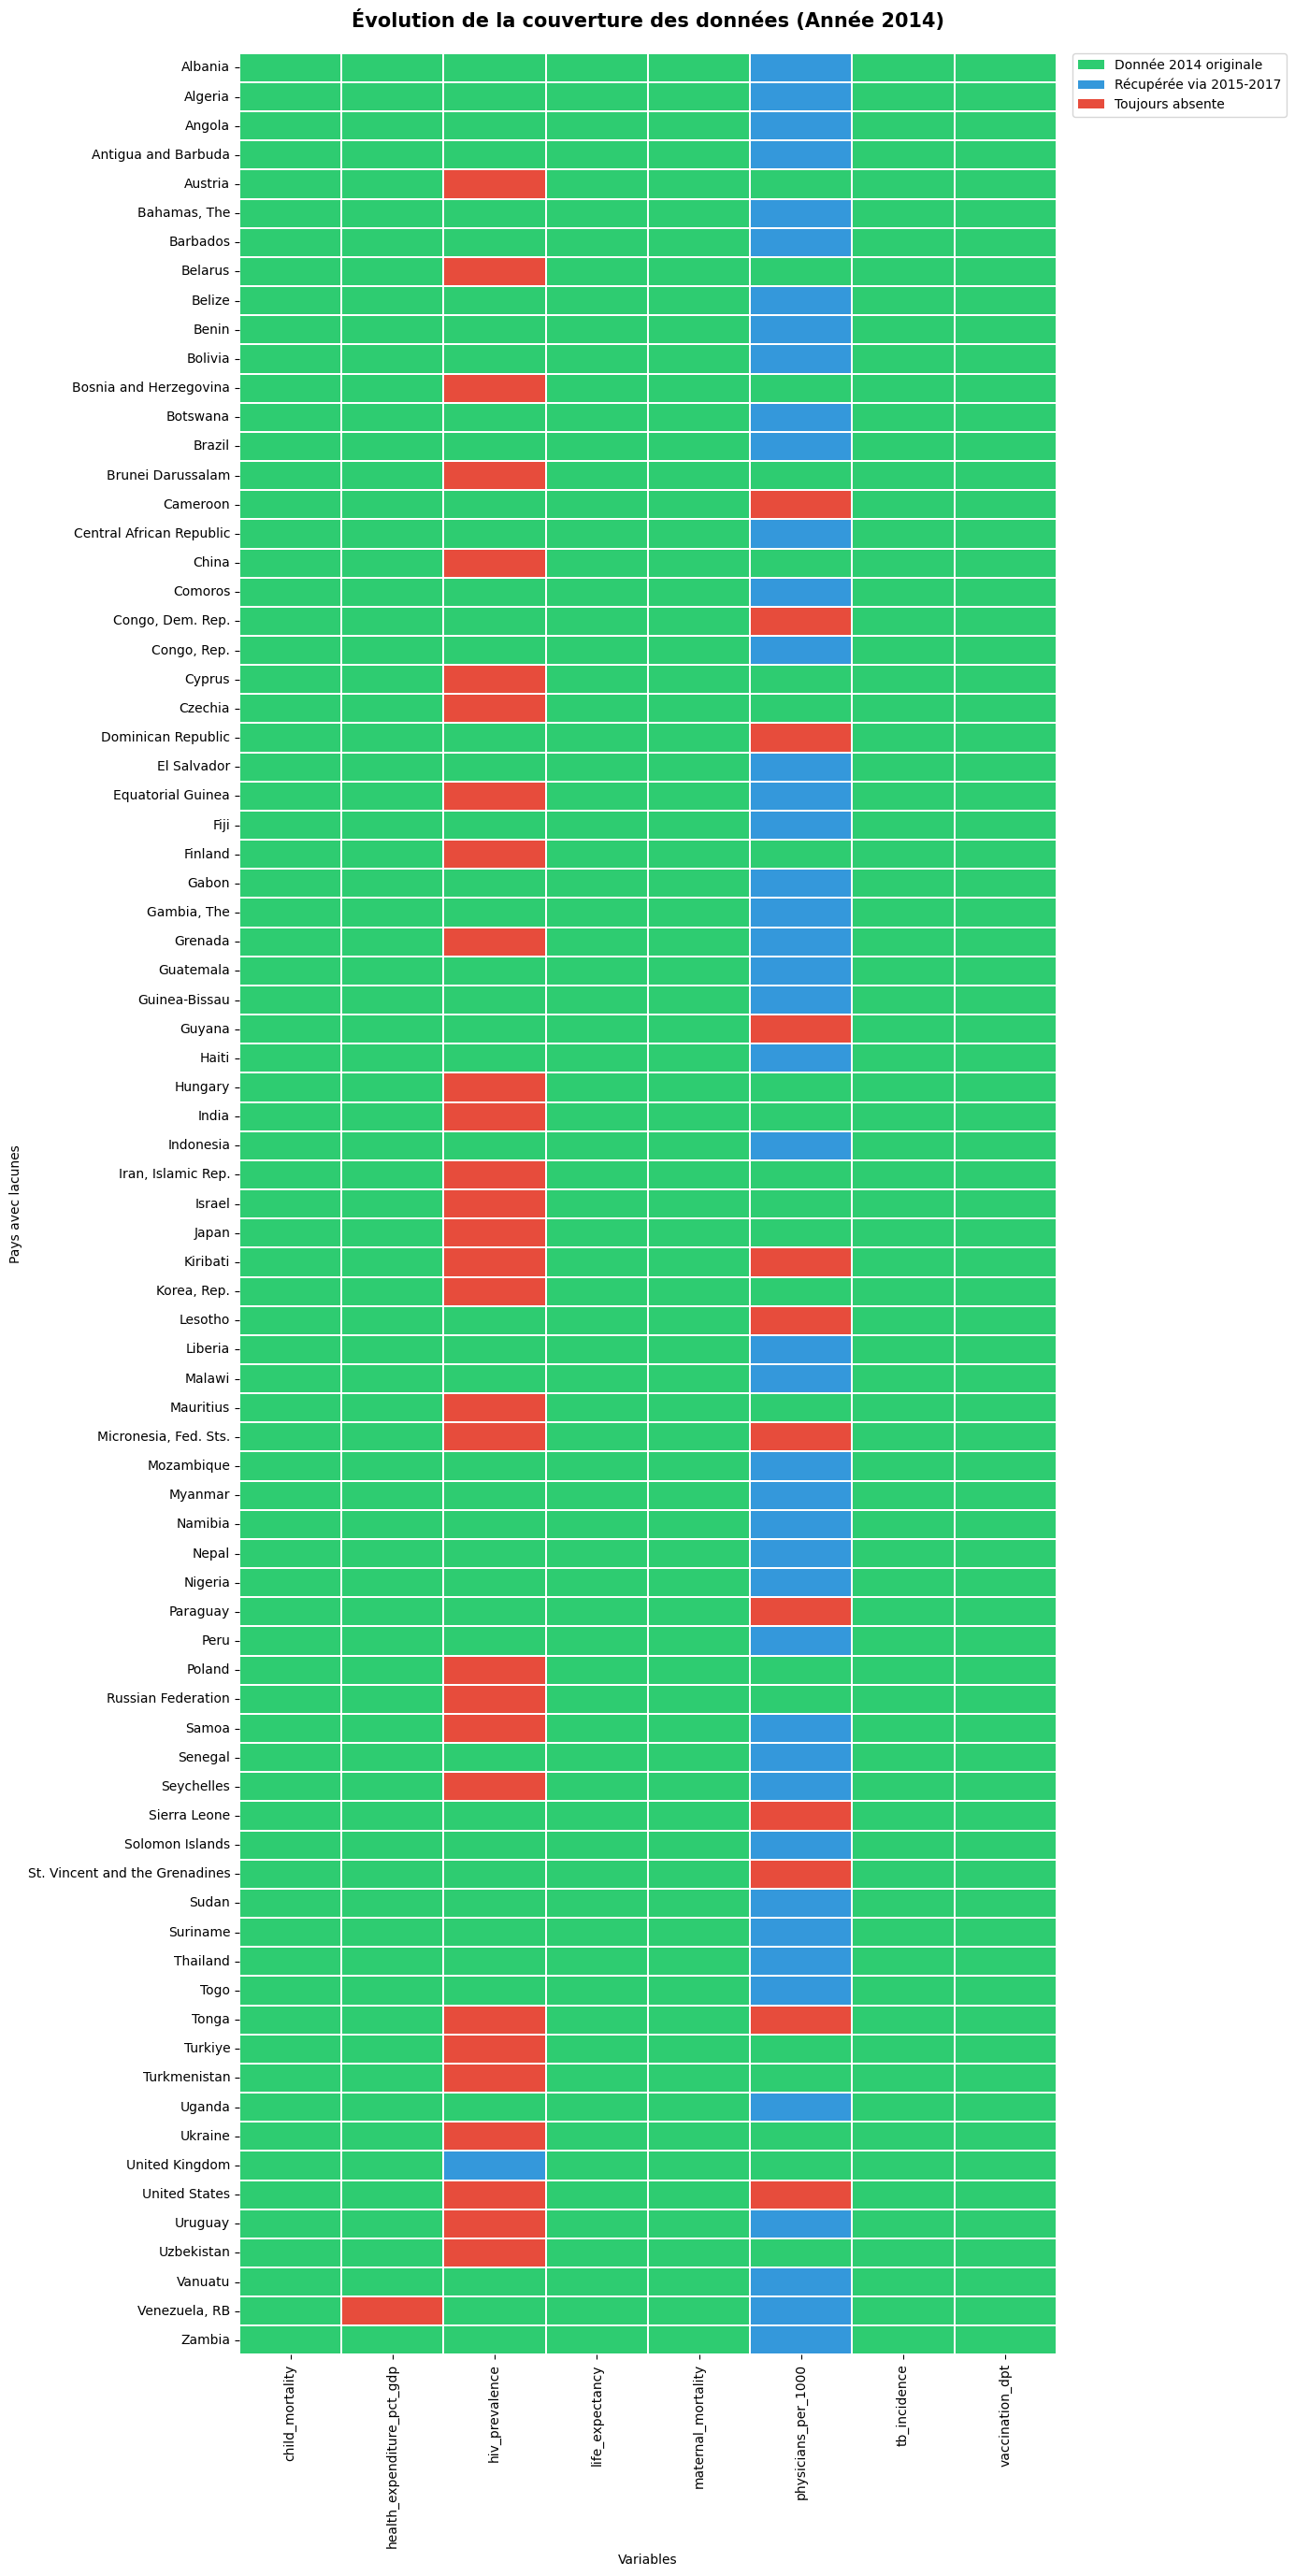

In [359]:
# Pivote la colonne 'status' pour visualiser l'origine de chaque point de donnée (Original, Récupéré, Absent).
df_pivot_status = df_wdi.pivot(index='Country', columns='series', values='status')

# Filtre pour afficher uniquement les pays qui avaient au moins une valeur manquante initiale ou finale.
df_viz = df_pivot_status[df_pivot_status.max(axis=1) > 0]

# Crée une carte de chaleur (heatmap) pour visualiser l'évolution de la couverture des données pour 2014.
plt.figure(figsize=(14, max(8, len(df_viz) * 0.35)))

# Définit une palette de couleurs stricte pour la carte de chaleur : Vert (Présent), Bleu (Récupéré), Rouge (NA).
colors = ["#2ecc71", "#3498db", "#e74c3c"]
sns.heatmap(df_viz, cmap=colors, cbar=False, linewidths=0.1, vmin=0, vmax=2)

# Ajoute une légende personnalisée pour expliquer le codage couleur.
legend_elements = [
    Patch(facecolor='#2ecc71', label='Donnée 2014 originale'),
    Patch(facecolor='#3498db', label='Récupérée via 2015-2017'),
    Patch(facecolor='#e74c3c', label='Toujours absente')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Évolution de la couverture des données (Année 2014)", fontsize=15, weight='bold', pad=20)
plt.ylabel("Pays avec lacunes")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

Certaines valeurs manquantes (NA) persistent et doivent être examinées par l'EDA (notebook P1).

**Fusion Main+Santé**

In [360]:
# Pivot the df_wdi DataFrame to have 'series' as columns and 'iso_code' as the index, taking 'YR2014' values.
df_h14_pivot = df_wdi.pivot(index='iso_code', columns='series', values='YR2014').reset_index()

# Merge the pivoted WDI data into the df_final DataFrame using 'iso_code' as the key.
# Use a left merge to keep all countries from df_final.
df_final = df_final.merge(df_h14_pivot, on="iso_code", how="left")

# Clean up any technical columns that might have been created during the merge (e.g., Unnamed columns).
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y')]

# Display the head of the updated df_final DataFrame.
df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code,child_mortality,health_expenditure_pct_gdp,hiv_prevalence,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG,74.6,9.528878,0.1,62.260,755.0,0.304,197.0,62.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB,9.9,6.358841,0.1,78.029,10.0,1.212,16.0,99.0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA,25.4,6.014841,0.1,74.992,80.0,1.819,80.0,95.0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO,64.5,2.156800,1.8,60.396,262.0,0.212,451.0,55.0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG,11.2,5.322183,0.9,76.912,32.0,2.917,3.4,99.0


In [361]:
# Calculate the number of null values for each column in df_final.
na_counts = df_final.isnull().sum()

# Count the number of unique countries that have at least one missing value.
countries_with_na = df_final[df_final.isnull().any(axis=1)]['country'].nunique()

print("--- État des lieux post-récupération et post-merge ---")
print(f"Nombre total de pays avec au moins un NA : {countries_with_na}")
print("\nDétail des NA par indicateur :")
# Print only columns that still have missing values.
print(na_counts[na_counts > 0])

--- État des lieux post-récupération et post-merge ---
Nombre total de pays avec au moins un NA : 39

Détail des NA par indicateur :
health_expenditure_pct_gdp     1
hiv_prevalence                30
physicians_per_1000           12
dtype: int64


### 2b.Dimension Santé WHO

In [362]:
df_who = pd.read_csv('data_raw_health_WHO.csv')
df_who.head()

,country_code,year,life_expectancy_who
0,TZA,2018,64.792958
1,DEU,2014,80.759927
2,ZAF,2015,60.006483
3,PRT,2019,84.149594
4,THA,2014,73.428103


La variable "life_expectancy" est déjà capturée dans sa version WDI ; l'information existe et est même présente dans le jeu de données original. Nous pouvons nous en passer.

## 3.Dimension pauvreté, nutrition et social

> En ouvrant l'un de ces jeux de données, on constate quelques erreurs dans les codes ISO, notamment ceux du Congo (décalage). Le plus simple ici serait de fusionner par le nom des pays et de trouver une solution *ad hoc* pour les cas problématiques.

In [363]:
# Update the wdi_to_iso_final dictionary with additional country name variations
# to improve ISO code mapping for social datasets.
wdi_to_iso_final.update({
    "Congo": "COD",
    "Micronesia": "FSM",
    "Korea": "KOR"
})

In [364]:
social_undernourishment = pd.read_excel('sous alimentation.xlsx')
social_schooling = pd.read_excel('scolarisation primaire nette.xlsx')
social_poverty_mpi = pd.read_excel('MPI — % pop en pauvrete multidim.xlsx')
social_literacy = pd.read_excel('literacy adult percentage.xlsx')
social_poverty_2_15 = pd.read_excel('Taux de pauvrete ( 2,15$jour PPP).xlsx')

In [365]:
# =========================================================
# Construction de la base sociale consolidée
# (sans fichier config)
# =========================================================

# Liste des datasets déjà importés
social_datasets = {
    "social_undernourishment": social_undernourishment,
    "social_schooling": social_schooling,
    "social_poverty_mpi": social_poverty_mpi,
    "social_literacy": social_literacy,
    "social_poverty_2_15": social_poverty_2_15
}

# =========================================================
# Base de référence
# =========================================================

df_social = pd.DataFrame(
    index=df_final['iso_code'].unique()
)

# =========================================================
# Boucle sur chaque dataset
# =========================================================

for key, df_tmp in social_datasets.items():

    print(f"\nTraitement : {key}")

    # -----------------------------------------------------
    # Nettoyage des noms de pays
    # -----------------------------------------------------

    df_tmp['Country Name'] = (
        df_tmp['Country Name']
        .astype(str)
        .str.strip()
    )

    # -----------------------------------------------------
    # Correction spécifique Congo
    # -----------------------------------------------------

    congo_mask = df_tmp['Country Name'] == 'Congo'

    if congo_mask.sum() >= 2:
        df_tmp.loc[df_tmp[congo_mask].index[0], 'iso_code'] = 'COD'
        df_tmp.loc[df_tmp[congo_mask].index[1], 'iso_code'] = 'COG'

    # -----------------------------------------------------
    # Mapping manuel ISO
    # -----------------------------------------------------

    mask_no_iso = df_tmp['iso_code'].isna()

    df_tmp.loc[mask_no_iso, 'iso_code'] = (
        df_tmp.loc[mask_no_iso, 'Country Name']
        .map(wdi_to_iso_final)
    )

    # -----------------------------------------------------
    # Fallback automatique
    # -----------------------------------------------------

    mask_still_no_iso = df_tmp['iso_code'].isna()

    df_tmp.loc[mask_still_no_iso, 'iso_code'] = (
        df_tmp.loc[mask_still_no_iso, 'Country Name']
        .apply(get_iso_code)
    )

    # -----------------------------------------------------
    # Suppression doublons
    # -----------------------------------------------------

    df_tmp = (
        df_tmp
        .drop_duplicates(subset='iso_code')
        .set_index('iso_code')
    )

    # -----------------------------------------------------
    # Colonnes années
    # -----------------------------------------------------

    years = [
        c for c in df_tmp.columns
        if isinstance(c, int)
        or (isinstance(c, str) and c.isdigit())
    ]

    # -----------------------------------------------------
    # Préfixage
    # -----------------------------------------------------

    df_to_merge = (
        df_tmp[years]
        .add_prefix(f"{key}_")
    )

    # -----------------------------------------------------
    # Fusion
    # -----------------------------------------------------

    df_social = df_social.join(
        df_to_merge,
        how='left'
    )

# =========================================================
# Vérification finale
# =========================================================

missing_final = df_social.index[
    df_social.isna().all(axis=1)
].tolist()

print(f"\nNombre de pays orphelins : {len(missing_final)}")

if len(missing_final) > 0:
    print("\nPays concernés :")
    print(missing_final)

# Aperçu
display(df_social.head())


Traitement : social_undernourishment

Traitement : social_schooling

Traitement : social_poverty_mpi

Traitement : social_literacy

Traitement : social_poverty_2_15

Nombre de pays orphelins : 0


,social_undernourishment_1960,social_undernourishment_1961,social_undernourishment_1962,social_undernourishment_1963,social_undernourishment_1964,social_undernourishment_1965,social_undernourishment_1966,social_undernourishment_1967,social_undernourishment_1968,social_undernourishment_1969,...,social_poverty_2_15_2016,social_poverty_2_15_2017,social_poverty_2_15_2018,social_poverty_2_15_2019,social_poverty_2_15_2020,social_poverty_2_15_2021,social_poverty_2_15_2022,social_poverty_2_15_2023,social_poverty_2_15_2024,social_poverty_2_15_2025
AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.1,1.4,1.0,0.3,0.3,NaN,NaN,NaN,NaN,NaN
DZA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,39.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Bilan des valeurs manquantes par indicateur social en 2014 :
                              Nombre de NA  Proportion de NA (%)
social_undernourishment_2014          18.0                  10.8
social_schooling_2014                 51.0                  30.5
social_poverty_mpi_2014              162.0                  97.0
social_literacy_2014                 137.0                  82.0
social_poverty_2_15_2014              88.0                  52.7


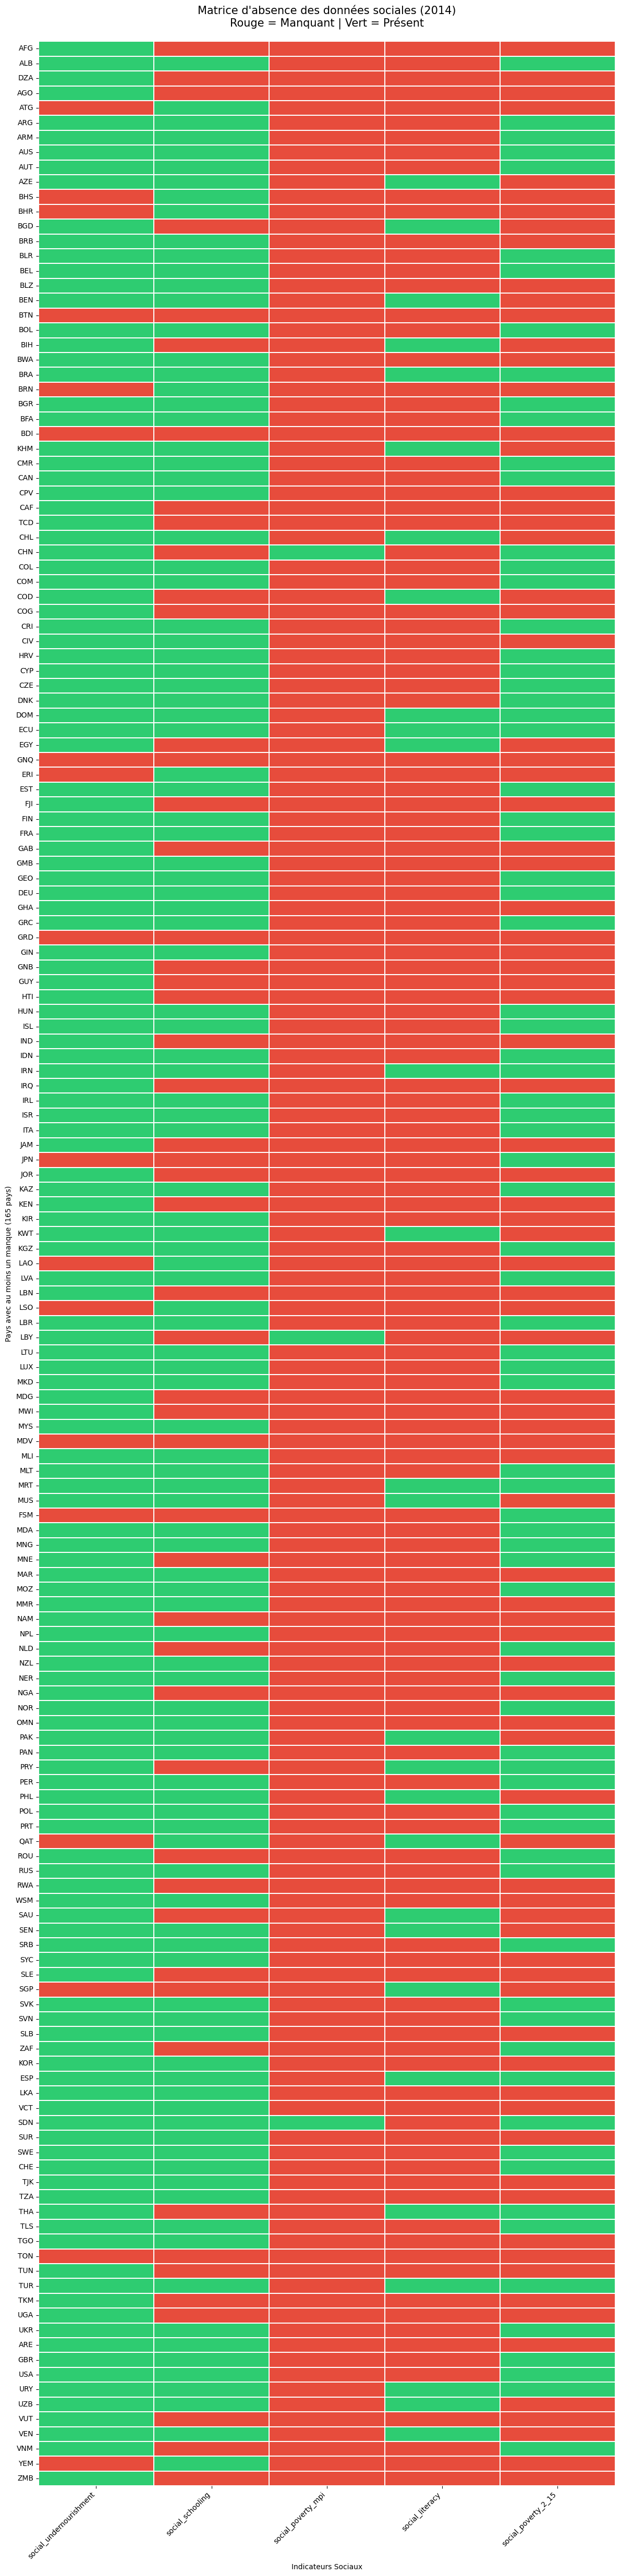

In [366]:
# Extract columns specific to the year 2014 for social indicators.
cols_2014 = [c for c in df_social.columns if c.endswith('_2014')]
df_social_2014 = df_social[cols_2014].copy()

# Create a boolean matrix indicating missing values (True if NA).
df_na_matrix = df_social_2014.isna()

# Calculate descriptive statistics (count and proportion of NAs) for each social indicator.
stats_na = df_na_matrix.agg(['sum', 'mean']).T
stats_na.columns = ['Nombre de NA', 'Proportion de NA']
stats_na['Proportion de NA (%)'] = (stats_na['Proportion de NA'] * 100).round(1)

print("Bilan des valeurs manquantes par indicateur social en 2014 :")
print(stats_na[['Nombre de NA', 'Proportion de NA (%)']])

# Prepare data for visualization: keep only countries with at least one missing value.
df_heat = df_na_matrix[df_na_matrix.any(axis=1)]

# Rename columns for clarity in the heatmap.
df_heat.columns = [c.replace('_2014', '') for c in df_heat.columns]

# Create a heatmap to visualize the missing data patterns for social indicators.
plt.figure(figsize=(12, max(8, len(df_heat) * 0.3)))
sns.heatmap(df_heat, cmap=['#2ecc71', '#e74c3c'], cbar=False, linewidths=0.1)

plt.title("Matrice d'absence des données sociales (2014)\nRouge = Manquant | Vert = Présent", fontsize=15, pad=20)
plt.xlabel("Indicateurs Sociaux")
plt.ylabel(f"Pays avec au moins un manque ({len(df_heat)} pays)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Recherche 2012-2016**

Entre 2010 et 2014, le monde a connu le Printemps Arabe, la création du Soudan du Sud, et des crises de la dette majeures.

Pourquoi 2012-2016 ? Car la plage temporelle est très grande et surtout le jeu de données contient de nombreuses valeurs manquantes (NA).

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


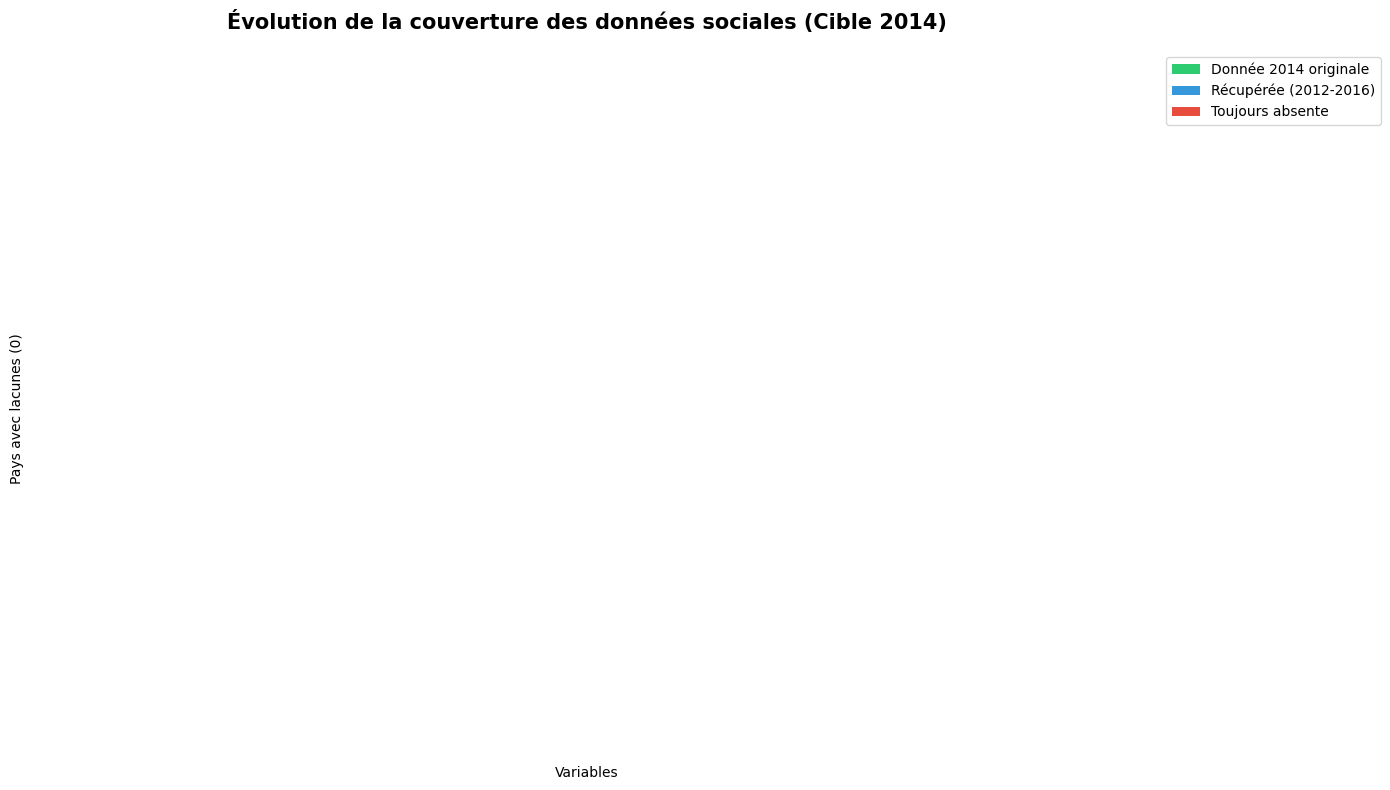

In [367]:
# Select the status columns created for each social indicator.
status_cols = [f"{key}_status" for key in social_keys]

# Filter for available status columns and create a visualization DataFrame.
available_status_cols = [c for c in status_cols if c in df_social.columns]
df_viz = df_social[available_status_cols].copy()

# Rename columns for clarity in the heatmap.
rename_map = {f"{key}_status": key for key in social_keys}
df_viz = df_viz.rename(columns=rename_map)

# Filter to show only countries that had data recovered or are still absent.
df_viz = df_viz[df_viz.max(axis=1) > 0]

# Create a heatmap to visualize the evolution of social data coverage for 2014.
plt.figure(figsize=(14, max(8, len(df_viz) * 0.35)))

# Define color palette for heatmap: Green (Original), Blue (Recovered), Red (Absent).
colors = ["#2ecc71", "#3498db", "#e74c3c"]
sns.heatmap(df_viz, cmap=colors, cbar=False, linewidths=0.1, vmin=0, vmax=2)

# Add a custom legend.
legend_elements = [
    Patch(facecolor='#2ecc71', label='Donnée 2014 originale'),
    Patch(facecolor='#3498db', label='Récupérée (2012-2016)'),
    Patch(facecolor='#e74c3c', label='Toujours absente')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Évolution de la couverture des données sociales (Cible 2014)", fontsize=15, weight='bold', pad=20)
plt.ylabel(f"Pays avec lacunes ({len(df_viz)})")
plt.xlabel("Variables")

plt.tight_layout()
plt.show()

**Fusion**

In [368]:
# 1. Préparation de la partie droite (sociale)
# On s'assure que l'index est bien nommé 'iso_code' avant le reset
df_social_final.index.name = 'iso_code'
df_social_to_merge = df_social_final.reset_index()

# 2. Vérification de la partie gauche (référentiel)
# Si iso_code est dans l'index de df_final, on le descend en colonne
if 'iso_code' not in df_final.columns:
    df_final = df_final.reset_index()

# 3. Fusion rigoureuse
# On spécifie explicitement les colonnes pour éviter toute ambiguïté
df_final = df_final.merge(df_social_to_merge, on="iso_code", how="left")

# 4. Nettoyage des suffixes et colonnes parasites
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y$')]

# Affichage du résultat pour confirmation
print(f"Nombre de pays : {len(df_final)}")
print(f"Colonnes actuelles : {df_final.columns.tolist()}")
df_final.head()

Nombre de pays : 167
Colonnes actuelles : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'iso_code', 'child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence', 'life_expectancy', 'maternal_mortality', 'physicians_per_1000', 'tb_incidence', 'vaccination_dpt', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt,social_poverty_mpi,social_literacy,social_poverty_2_15,social_schooling,social_undernourishment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,62.260,755.0,0.304,197.0,62.0,NaN,33.750000,NaN,NaN,19.3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,78.029,10.0,1.212,16.0,99.0,NaN,97.250000,3.7,93.78369,4.6
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,74.992,80.0,1.819,80.0,95.0,NaN,NaN,0.0,97.54838,2.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,60.396,262.0,0.212,451.0,55.0,51.1,66.029999,NaN,78.02393,13.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,76.912,32.0,2.917,3.4,99.0,NaN,NaN,NaN,91.88907,NaN


In [369]:
status_data = {}
consolidated_2014 = {}

for key in social_keys:
    col_2014 = f"{key}_2014"

    # Capture the initial state of NA values for the 2014 column.
    initial_na = df_social[col_2014].isna()

    # Work on a copy of the 2014 series to avoid iterative modifications.
    series_2014 = df_social[col_2014].copy()

    # Define a list of years to search for missing data (backfilling).
    search_years = [2015, 2013, 2016, 2011, 2010]

    # Attempt to fill NA values in series_2014 using data from other years.
    for yr in search_years:
        col_yr = f"{key}_{yr}"
        if col_yr in df_social.columns:
            series_2014 = series_2014.fillna(df_social[col_yr])

    # Store the consolidated 2014 series.
    consolidated_2014[col_2014] = series_2014

    # Determine the status of each data point (0: Original, 1: Recovered, 2: Absent).
    status = pd.Series(0, index=df_social.index)
    status.loc[initial_na & series_2014.notna()] = 1
    status.loc[series_2014.isna()] = 2
    status_data[f"{key}_status"] = status

# Create DataFrames from the collected status and consolidated data.
df_status = pd.DataFrame(status_data)
df_social_final = pd.DataFrame(consolidated_2014)

# Update df_social by concatenating the status DataFrame.
df_social = pd.concat([df_social, df_status], axis=1)

# Rename columns in df_social_final for cleaner representation.
df_social_final.columns = social_keys

/tmp/ipykernel_31054/3665293777.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_na_final['Proportion de NA (%)'], y=stats_na_final.index, palette='Reds_r')


Bilan de la complétude des variables sociales (après consolidation) :
                         Nombre de NA  Proportion de NA (%)
social_poverty_mpi              143.0                 85.63
social_literacy                  79.0                 47.31
social_poverty_2_15              39.0                 23.35
social_undernourishment          18.0                 10.78
social_schooling                 16.0                  9.58


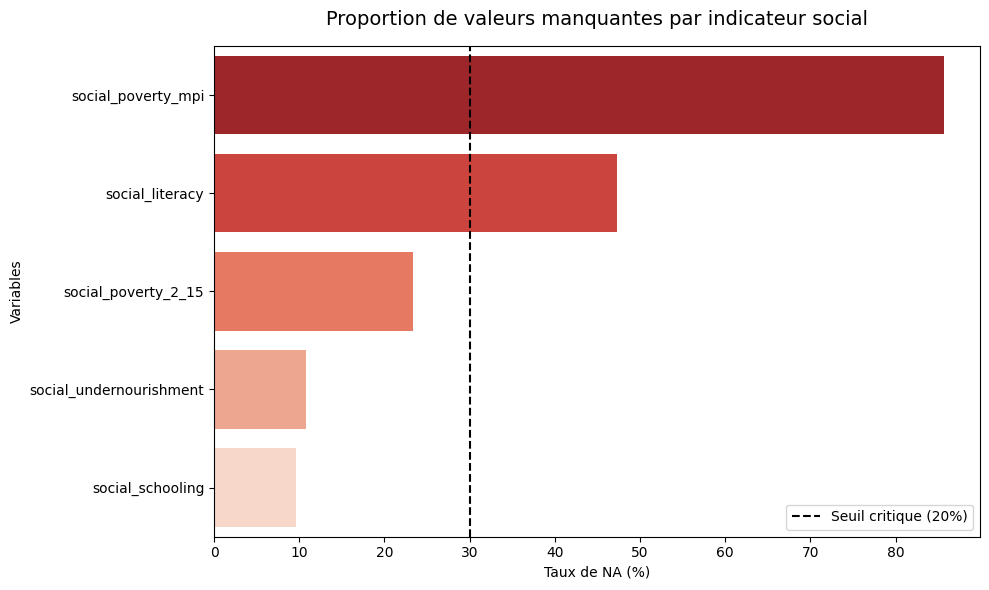

In [370]:
# Identify the social columns that have been integrated into df_final.
# Calculate the number and proportion of NA values for each social variable.
stats_na_final = df_final[social_keys].isna().agg(['sum', 'mean']).T
stats_na_final.columns = ['Nombre de NA', 'Proportion de NA']

# Format the proportion as a percentage and sort by the number of NAs.
stats_na_final['Proportion de NA (%)'] = (stats_na_final['Proportion de NA'] * 100).round(2)
stats_na_final = stats_na_final.sort_values(by='Nombre de NA', ascending=False)

print("Bilan de la complétude des variables sociales (après consolidation) :")
print(stats_na_final[['Nombre de NA', 'Proportion de NA (%)']])

# Visualize the proportion of missing values for social indicators using a bar plot.
plt.figure(figsize=(10, 6))
sns.barplot(x=stats_na_final['Proportion de NA (%)'], y=stats_na_final.index, palette='Reds_r')

# Add a critical threshold line (30%) for visual reference.
plt.axvline(x=30, color='black', linestyle='--', label='Seuil critique (20%)')

plt.title("Proportion de valeurs manquantes par indicateur social", fontsize=14, pad=15)
plt.xlabel("Taux de NA (%)")
plt.ylabel("Variables")
plt.legend()
plt.tight_layout()
plt.show()

In [371]:
# 1. Préparation de la partie droite (sociale)
# On s'assure que l'index est bien nommé 'iso_code' avant le reset
df_social_final.index.name = 'iso_code'
df_social_to_merge = df_social_final.reset_index()

# 2. Vérification de la partie gauche (référentiel)
# Si iso_code est dans l'index de df_final, on le descend en colonne
if 'iso_code' not in df_final.columns:
    df_final = df_final.reset_index()

# Identify social columns to be merged
social_cols_to_merge = df_social_to_merge.columns.drop('iso_code', errors='ignore').tolist()

# Drop any existing social columns from df_final (and potential _x suffixes from previous failed merges)
# This prevents MergeError in case of re-runs or inconsistent state
for col in social_cols_to_merge:
    if col in df_final.columns:
        df_final = df_final.drop(columns=[col])
    if f"{col}_x" in df_final.columns: # Also check for _x suffixes from previous partial merges
        df_final = df_final.drop(columns=[f"{col}_x"])

# 3. Fusion rigoureuse
# On spécifie explicitement les colonnes pour éviter toute ambiguïté
df_final = df_final.merge(df_social_to_merge, on="iso_code", how="left")

# 4. Nettoyage des suffixes et colonnes parasites
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y$')]

# Renommer les variables santé dans df_final
df_final = df_final.rename(columns={

    "Life expectancy at birth, total (years)":
        "life_expectancy",

    "Maternal mortality ratio (modeled estimate, per 100,000 live births)":
        "maternal_mortality",

    "Mortality rate, under-5 (per 1,000 live births)":
        "child_mortality",

    "Physicians (per 1,000 people)":
        "physicians_per_1000",

    "Prevalence of HIV, total (% of population ages 15-49)":
        "hiv_prevalence"

})

# Vérification
print(df_final.columns.tolist())
# Affichage du résultat pour confirmation
print(f"Nombre de pays : {len(df_final)}")
print(f"Colonnes actuelles : {df_final.columns.tolist()}")
df_final.head()

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'iso_code', 'child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence', 'life_expectancy', 'maternal_mortality', 'physicians_per_1000', 'tb_incidence', 'vaccination_dpt', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment']
Nombre de pays : 167
Colonnes actuelles : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'iso_code', 'child_mortality', 'health_expenditure_pct_gdp', 'hiv_prevalence', 'life_expectancy', 'maternal_mortality', 'physicians_per_1000', 'tb_incidence', 'vaccination_dpt', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt,social_poverty_mpi,social_literacy,social_poverty_2_15,social_schooling,social_undernourishment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,62.260,755.0,0.304,197.0,62.0,NaN,33.750000,NaN,NaN,19.3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,78.029,10.0,1.212,16.0,99.0,NaN,97.250000,3.7,93.78369,4.6
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,74.992,80.0,1.819,80.0,95.0,NaN,NaN,0.0,97.54838,2.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,60.396,262.0,0.212,451.0,55.0,51.1,66.029999,NaN,78.02393,13.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,76.912,32.0,2.917,3.4,99.0,NaN,NaN,NaN,91.88907,NaN


In [372]:
# Print the final dimensions of the merged DataFrame.
print(f"Taille finale : {df_final.shape}")
# Verify that all 167 countries are still present in the DataFrame.
print(f"Nombre de pays : {df_final['country'].nunique()} (les 167 sont bien présents)")


Taille finale : (167, 24)
Nombre de pays : 167 (les 167 sont bien présents)


# 4.Dimension Sécurité

Il s'agit des données de l'indice de l'État fragile (FSI) de 2015. Nous allons le fusionner avec le fichier country-data.csv afin de standardiser les noms de pays et explorer les caractéristiques clés du dataframe résultant.

In [373]:
 #Charger fsi-2015.xlsx #Les données des rapports FSI correspondent à la situation
#de l'année précédente. Le FSI 2020, par exemple, couvre les données collectées
#entre le 1er janvier 2019 et le 31 décembre 2019. La même logique s'applique
#à toutes les autres années.
fsi_df = pd.read_excel('fsi-2015.xlsx')
print("Variables dans fsi-2015.xlsx:")
print(fsi_df.columns.tolist())
print("\nPremières 5 lignes de fsi-2015.xlsx:")
display(fsi_df.head())

Variables dans fsi-2015.xlsx:
['Country', 'Year', 'Rank', 'Total', 'C1: Security Apparatus', 'C2: Factionalized Elites', 'C3: Group Grievance', 'E1: Economy', 'E2: Economic Inequality', 'E3: Human Flight and Brain Drain', 'P1: State Legitimacy', 'P2: Public Services', 'P3: Human Rights', 'S1: Demographic Pressures', 'S2: Refugees and IDPs', 'X1: External Intervention']

Premières 5 lignes de fsi-2015.xlsx:


,Country,Year,Rank,Total,C1: Security Apparatus,C2: Factionalized Elites,C3: Group Grievance,E1: Economy,E2: Economic Inequality,E3: Human Flight and Brain Drain,P1: State Legitimacy,P2: Public Services,P3: Human Rights,S1: Demographic Pressures,S2: Refugees and IDPs,X1: External Intervention
0,South Sudan,2015-01-01,1st,114.5,10.0,10.0,10.0,9.0,8.8,6.9,10.0,10.0,10.0,9.8,10.0,10.0
1,Somalia,2015-01-01,2nd,114.0,9.7,10.0,9.5,9.1,9.0,9.2,9.3,9.3,10.0,9.6,9.8,9.5
2,Central African Republic,2015-01-01,3rd,111.9,9.8,10.0,9.6,8.3,9.7,6.9,9.5,9.9,10.0,8.4,10.0,9.8
3,Sudan,2015-01-01,4th,110.8,9.5,9.8,9.7,8.6,7.9,8.8,9.6,8.8,9.6,8.7,10.0,9.8
4,Congo Democratic Republic,2015-01-01,5th,109.7,9.5,9.5,9.5,7.9,8.8,7.1,9.0,9.7,10.0,9.5,9.4,9.8


In [374]:
# Vérifier les colonnes disponibles
print("Colonnes disponibles :")
print(fsi_df.columns.tolist())

# Afficher les modalités uniques de la variable country
modalites = fsi_df["Country"].dropna().unique()

print("\nModalités de la variable 'country' :")
for m in sorted(modalites):
    print(m)

# Nombre de modalités
print(f"\nNombre total de modalités : {len(modalites)}")

Colonnes disponibles :
['Country', 'Year', 'Rank', 'Total', 'C1: Security Apparatus', 'C2: Factionalized Elites', 'C3: Group Grievance', 'E1: Economy', 'E2: Economic Inequality', 'E3: Human Flight and Brain Drain', 'P1: State Legitimacy', 'P2: Public Services', 'P3: Human Rights', 'S1: Demographic Pressures', 'S2: Refugees and IDPs', 'X1: External Intervention']

Modalités de la variable 'country' :
Afghanistan
Albania
Algeria
Angola
Antigua and Barbuda
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Brunei Darussalam
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Cape Verde
Central African Republic
Chad
Chile
China
Colombia
Comoros
Congo Democratic Republic
Congo Republic
Costa Rica
Cote d'Ivoire
Croatia
Cuba
Cyprus
Czech Republic
Denmark
Djibouti
Dominican Republic
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Ethiopia
Fiji
Finland
France
Gabon
G

In [375]:
# Charger Country-data.xlsx
country_data_df = pd.read_excel('Country-data.xlsx')
# Supprimer toutes les variables sauf 'country'
country_data_df = country_data_df[['country']]

print(country_data_df.columns.tolist())
# Afficher les modalités uniques de la variable country
modalites = country_data_df["country"].dropna().unique()

print("\nModalités de la variable 'country' :")
for m in sorted(modalites):
    print(m)

# Nombre de modalités
print(f"\nNombre total de modalités : {len(modalites)}")

['country']

Modalités de la variable 'country' :
Afghanistan
Albania
Algeria
Angola
Antigua and Barbuda
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Brunei
Bulgaria
Burkina Faso
Burundi
Cambodia
Cameroon
Canada
Cape Verde
Central African Republic
Chad
Chile
China
Colombia
Comoros
Congo, Dem. Rep.
Congo, Rep.
Costa Rica
Cote d'Ivoire
Croatia
Cyprus
Czech Republic
Denmark
Dominican Republic
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Fiji
Finland
France
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Grenada
Guatemala
Guinea
Guinea-Bissau
Guyana
Haiti
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kiribati
Kuwait
Kyrgyz Republic
Lao
Latvia
Lebanon
Lesotho
Liberia
Libya
Lithuania
Luxembourg
Macedonia, FYR
Madagascar
Malawi
Malaysia
Maldives
Mali
Malta
Mauritania
Mauritius
Micronesia, Fed. Sts.
Moldova
Mong

Maintenant, listons les noms de pays uniques de `Country-data.xlsx` pour les utiliser comme référence pour la standardisation.

In [376]:
# Identifier la colonne du pays dans country_data_df
# En supposant que la colonne du pays est 'Country' ou 'country' selon les modèles courants et l'invite de l'utilisateur
country_col_name = None
for col in country_data_df.columns:
    if 'country' in col:
        country_col_name = col
        break

if country_col_name:
    print(f"Modalités de pays uniques dans {country_col_name} de Country-data.xlsx:")
    unique_countries = country_data_df[country_col_name].unique().tolist()
    print(unique_countries)
else:
    print("Impossible de trouver une colonne 'Country' ou 'pays' dans Country-data.xlsx. Veuillez vérifier les noms des colonnes.")

Modalités de pays uniques dans country de Country-data.xlsx:
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica'

Fusion de `fsi_df` et `country_data_df`

In [377]:
print("Pays uniques dans fsi-2015.xlsx avant standardisation:")
print(fsi_df['Country'].unique().tolist())

# Créer un mappage pour les noms de pays dans fsi_df pour correspondre à country_data_df
# Ce mappage corrige les incohérences courantes trouvées en comparant les listes uniques.
country_mapping_fsi = {
    'Congo Democratic Republic': 'Congo, Dem. Rep.',
    'Congo Republic': 'Congo, Rep.',
    'Guinea Bissau': 'Guinea-Bissau',
    'Macedonia': 'Macedonia, FYR',
    'Micronesia': 'Micronesia, Fed. Sts.',
    'Slovak Republic': 'Slovak Republic',
    'Timor-Leste': 'Timor-Leste',
    'Brunei Darussalam': 'Brunei',
    'Cote d\'Ivoire': 'Cote d\'Ivoire',
    'Israel and West Bank': 'Israel',
    'Kyrgyz Republic': 'Kyrgyz Republic',
    'Laos': 'Lao',
    'Swaziland': 'Swaziland',
    'Syria': 'Syria',
    'Trinidad and Tobago': 'Trinidad and Tobago',
    'United Kingdom': 'United Kingdom',
    'United States': 'United States',
    'Venezuela': 'Venezuela',
    'Vietnam': 'Vietnam',
    'Somalia': 'Somalia',
    'South Sudan': 'South Sudan'
}

# Appliquer le mappage pour créer une nouvelle colonne de pays standardisée
fsi_df['Country_Standardized'] = fsi_df['Country'].replace(country_mapping_fsi)

# --- DEBUG: Vérifier 'Brunei' après le mappage ---
print(f"\nPrésence de 'Brunei Darussalam' dans fsi_df['Country'] avant le mappage : {'Brunei Darussalam' in fsi_df['Country'].unique()}")
print(f"Présence de 'Brunei' dans fsi_df['Country_Standardized'] APRES le mappage : {'Brunei' in fsi_df['Country_Standardized'].unique()}")
print(f"Présence de 'Brunei' dans la liste de référence unique_countries : {'Brunei' in unique_countries}")
# --- FIN DEBUG ---

# Filtrer fsi_df pour ne garder que les pays présents dans unique_countries
initial_fsi_count = len(fsi_df)
fsi_df = fsi_df[fsi_df['Country_Standardized'].isin(unique_countries)].copy() # Utilisation de .copy() pour éviter SettingWithCopyWarning
print(f"Nombre de pays dans fsi-2015.xlsx avant filtrage: {initial_fsi_count}")
print(f"Nombre de pays dans fsi-2015.xlsx après filtrage (correspondant à Country-data.xlsx): {len(fsi_df)}")

# --- DEBUG: Vérifier 'Brunei' après le filtrage ---
print(f"Présence de 'Brunei' dans fsi_df['Country_Standardized'] APRES le filtrage : {'Brunei' in fsi_df['Country_Standardized'].unique()}")
# --- FIN DEBUG ---


# Identifier les pays dans fsi_df qui ne sont toujours pas dans la liste de référence après le mappage (devrait être vide maintenant si le filtre a fonctionné correctement sur les noms standardisés)
countries_not_in_country_data_after_fsi_mapping = [country for country in fsi_df['Country_Standardized'].unique() if country not in unique_countries]

print("\nPays dans fsi-2015.xlsx non trouvés dans Country-data.xlsx après le mappage initial (devrait être vide): ")
print(countries_not_in_country_data_after_fsi_mapping)

# Afficher les premières lignes avec les noms de pays originaux et standardisés
print("\nPremières 5 lignes de fsi-2015.xlsx avec les noms de pays originaux et standardisés:")
display(fsi_df[['Country', 'Country_Standardized']].head(167))

Pays uniques dans fsi-2015.xlsx avant standardisation:
['South Sudan', 'Somalia', 'Central African Republic', 'Sudan', 'Congo Democratic Republic', 'Chad', 'Yemen', 'Afghanistan', 'Syria', 'Guinea', 'Haiti', 'Iraq', 'Pakistan', 'Nigeria', "Cote d'Ivoire", 'Zimbabwe', 'Guinea Bissau', 'Burundi', 'Niger', 'Ethiopia', 'Kenya', 'Liberia', 'Uganda', 'Eritrea', 'Libya', 'Mauritania', 'Myanmar', 'Cameroon', 'North Korea', 'Mali', 'Sierra Leone', 'Bangladesh', 'Congo Republic', 'Sri Lanka', 'Nepal', 'Timor-Leste', 'Rwanda', 'Egypt', 'Burkina Faso', 'Lebanon', 'Djibouti', 'Angola', 'Cambodia', 'Iran', 'Malawi', 'Mozambique', 'Togo', 'Philippines', 'Swaziland', 'Solomon Islands', 'Gambia', 'Uzbekistan', 'Zambia', 'Equatorial Guinea', 'Laos', 'Madagascar', 'Papua New Guinea', 'Tajikistan', 'Comoros', 'Senegal', 'Colombia', 'Kyrgyz Republic', 'Tanzania', 'Guatemala', 'Russia', 'Lesotho', 'Algeria', 'Israel and West Bank', 'India', 'Georgia', 'Thailand', 'Nicaragua', 'Benin', 'Bhutan', 'Venezuela',

,Country,Country_Standardized
2,Central African Republic,Central African Republic
3,Sudan,Sudan
4,Congo Democratic Republic,"Congo, Dem. Rep."
5,Chad,Chad
6,Yemen,Yemen
...,...,...
173,Luxembourg,Luxembourg
174,Denmark,Denmark
175,Norway,Norway
176,Sweden,Sweden


In [378]:
# Fusionner avec country_data_df pour des données supplémentaires au niveau du pays et l'utiliser comme base pour les noms de pays
# Renommer la colonne 'country' dans country_data_df en 'Country_Standardized' pour la fusion
country_data_renamed = country_data_df.rename(columns={'country': 'Country_Standardized'})

# Effectuer une fusion droite avec country_data_df pour conserver tous les pays du main dataset
fsi_merged_df = pd.merge(fsi_df, country_data_renamed, on='Country_Standardized', how='right')

# GARDER UNIQUEMENT LES VARIABLES DE SÉCURITÉ FSI
fsi_merged_df = fsi_merged_df[[
    "Country_Standardized",
    'C1: Security Apparatus',
    'C2: Factionalized Elites',
    'C3: Group Grievance',
    'S1: Demographic Pressures',
    'S2: Refugees and IDPs',
    'P3: Human Rights',
    'X1: External Intervention'
]].copy()

# Renommage
fsi_merged_df = fsi_merged_df.rename(columns={

    "Country_Standardized": "country",
    "C1: Security Apparatus": "security_apparatus",
    "C2: Factionalized Elites": "factionalized_elites",
    "C3: Group Grievance": "group_grievance",
    "S1: Demographic Pressures":"demo_pressure",
    "S2: Refugees and IDPs": "refugees_idps",
    "P3: Human Rights":"human_rights",
    "X1: External Intervention": "external_intervention"

})

# Aperçu
display(fsi_merged_df.head())
print("Forme du dataframe fusionné final (fsi_merged_df):", fsi_merged_df.shape)
print("Colonnes du dataframe fusionné final (fsi_merged_df):")
print(fsi_merged_df.columns.tolist())
print("\nLignes du dataframe fusionné final (fsi_merged_df):")
display(fsi_merged_df.head(167))

,country,security_apparatus,factionalized_elites,group_grievance,demo_pressure,refugees_idps,human_rights,external_intervention
0,Afghanistan,10.0,9.3,8.9,9.3,9.1,8.6,9.8
1,Albania,4.7,6.2,5.0,4.1,3.1,5.5,6.1
2,Algeria,8.0,7.7,8.2,5.7,6.4,7.1,5.4
3,Angola,6.0,7.2,7.3,8.7,7.6,7.3,5.6
4,Antigua and Barbuda,5.2,3.7,3.9,4.6,3.0,4.5,5.8


Forme du dataframe fusionné final (fsi_merged_df): (167, 8)
Colonnes du dataframe fusionné final (fsi_merged_df):
['country', 'security_apparatus', 'factionalized_elites', 'group_grievance', 'demo_pressure', 'refugees_idps', 'human_rights', 'external_intervention']

Lignes du dataframe fusionné final (fsi_merged_df):


,country,security_apparatus,factionalized_elites,group_grievance,demo_pressure,refugees_idps,human_rights,external_intervention
0,Afghanistan,10.0,9.3,8.9,9.3,9.1,8.6,9.8
1,Albania,4.7,6.2,5.0,4.1,3.1,5.5,6.1
2,Algeria,8.0,7.7,8.2,5.7,6.4,7.1,5.4
3,Angola,6.0,7.2,7.3,8.7,7.6,7.3,5.6
4,Antigua and Barbuda,5.2,3.7,3.9,4.6,3.0,4.5,5.8
...,...,...,...,...,...,...,...,...
162,Vanuatu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,Venezuela,6.5,8.1,7.3,5.1,4.8,8.3,4.3
164,Vietnam,5.1,6.9,6.5,6.1,4.7,7.8,5.1
165,Yemen,10.0,9.4,9.4,9.2,9.1,9.1,9.5


**fusion**

In [379]:
df_final

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt,social_poverty_mpi,social_literacy,social_poverty_2_15,social_schooling,social_undernourishment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,62.260,755.0,0.304,197.0,62.0,NaN,33.750000,NaN,NaN,19.3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,78.029,10.0,1.212,16.0,99.0,NaN,97.250000,3.7,93.78369,4.6
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,74.992,80.0,1.819,80.0,95.0,NaN,NaN,0.0,97.54838,2.7
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,60.396,262.0,0.212,451.0,55.0,51.1,66.029999,NaN,78.02393,13.2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,76.912,32.0,2.917,3.4,99.0,NaN,NaN,NaN,91.88907,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,...,70.043,110.0,0.169,89.0,86.0,NaN,NaN,25.7,79.84105,7.4
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,...,72.837,133.0,1.664,29.0,78.0,NaN,95.987189,NaN,91.56032,2.5
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,...,73.886,59.0,0.783,205.0,95.0,NaN,93.519997,3.4,97.96511,8.3
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,...,68.003,134.0,0.270,43.0,70.0,NaN,NaN,33.3,85.43356,NaN


In [380]:
# Définir le mappage des noms de pays de df_final vers fsi_merged_df
country_rename_mapping = {
    'Russian Federation': 'Russia',
    'North Macedonia': 'Macedonia, FYR',
    'Cabo Verde': 'Cape Verde',
    "Côte d'Ivoire": "Cote d'Ivoire",
    'Brunei Darussalam': 'Brunei',
    'Saint Vincent and the Grenadines': 'St. Vincent and the Grenadines',
    'Congo, The Democratic Republic of the': 'Congo, Dem. Rep.',
    'Türkiye': 'Turkey',
    'Micronesia, Federated States of': 'Micronesia, Fed. Sts.',
    'Congo': 'Congo, Rep.'
}

# Appliquer le renommage à la colonne 'country' de df_final
df_final['country'] = df_final['country'].replace(country_rename_mapping)

print("Les pays dans df_final ont été renommés selon le mappage.")

# Vérifier à nouveau les noms de pays après le renommage
pays_df_final_renommés = set(df_final['country'].unique())
pays_fsi_merged = set(fsi_merged_df['country'].unique())

print(f"\nNombre de pays uniques dans df_final après renommage : {len(pays_df_final_renommés)}")
print(f"Nombre de pays uniques dans fsi_merged_df : {len(pays_fsi_merged)}")

pays_communs_après_renommage = pays_df_final_renommés.intersection(pays_fsi_merged)
print(f"\nNombre de pays en commun après renommage : {len(pays_communs_après_renommage)}")
print("Pays en commun après renommage (10 premiers) :\n", list(pays_communs_après_renommage)[:10])

pays_uniquement_dans_df_final_après_renommage = pays_df_final_renommés.difference(pays_fsi_merged)
print(f"\nNombre de pays uniquement dans df_final après renommage : {len(pays_uniquement_dans_df_final_après_renommage)}")
print("Pays uniquement dans df_final après renommage (10 premiers) :\n", list(pays_uniquement_dans_df_final_après_renommage)[:10])

Les pays dans df_final ont été renommés selon le mappage.

Nombre de pays uniques dans df_final après renommage : 167
Nombre de pays uniques dans fsi_merged_df : 167

Nombre de pays en commun après renommage : 167
Pays en commun après renommage (10 premiers) :
 ['Kazakhstan', 'France', 'Australia', 'Algeria', 'China', 'Montenegro', 'Guinea-Bissau', 'Niger', 'Malta', 'Macedonia, FYR']

Nombre de pays uniquement dans df_final après renommage : 0
Pays uniquement dans df_final après renommage (10 premiers) :
 []


# Section 2 : Dernière fusion

In [381]:
# Utiliser une fusion interne pour ne garder que les pays correspondants.
df_final = pd.merge(df_final, fsi_merged_df, left_on='country', right_on='country', how='inner')

print(f'Dimensions du DataFrame fusionné après renommage et refusion : {df_final.shape}')
print('\nLes 5 premières lignes du DataFrame refusionné :')
display(df_final.head())

Dimensions du DataFrame fusionné après renommage et refusion : (167, 31)

Les 5 premières lignes du DataFrame refusionné :


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,social_poverty_2_15,social_schooling,social_undernourishment,security_apparatus,factionalized_elites,group_grievance,demo_pressure,refugees_idps,human_rights,external_intervention
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,NaN,NaN,19.3,10.0,9.3,8.9,9.3,9.1,8.6,9.8
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,3.7,93.78369,4.6,4.7,6.2,5.0,4.1,3.1,5.5,6.1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,0.0,97.54838,2.7,8.0,7.7,8.2,5.7,6.4,7.1,5.4
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,NaN,78.02393,13.2,6.0,7.2,7.3,8.7,7.6,7.3,5.6
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,NaN,91.88907,NaN,5.2,3.7,3.9,4.6,3.0,4.5,5.8


In [382]:
display(df_final.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,social_poverty_2_15,social_schooling,social_undernourishment,security_apparatus,factionalized_elites,group_grievance,demo_pressure,refugees_idps,human_rights,external_intervention
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,NaN,NaN,19.3,10.0,9.3,8.9,9.3,9.1,8.6,9.8
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,3.7,93.78369,4.6,4.7,6.2,5.0,4.1,3.1,5.5,6.1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,0.0,97.54838,2.7,8.0,7.7,8.2,5.7,6.4,7.1,5.4
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,NaN,78.02393,13.2,6.0,7.2,7.3,8.7,7.6,7.3,5.6
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,NaN,91.88907,NaN,5.2,3.7,3.9,4.6,3.0,4.5,5.8


In [383]:
# Enregistrement du DataFrame final dans un fichier Excel
df_final.to_excel(
    "df_fusionnes.xlsx",
    index=False
)

print("Fichier 'df_fusionnes.xlsx' enregistré avec succès.")

# Téléchargement automatique du fichier
from google.colab import files

files.download("df_fusionnes.xlsx")

Fichier 'df_fusionnes.xlsx' enregistré avec succès.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# FIN